# 熱影像人數偵測與環境感測器數據分析

本 Notebook 用於分析 Supabase 中的兩張表：
- `people_count_results`: 人數偵測結果
- `wiolink`: 環境感測器數據

## 分析內容

1. **時間序列分析**：人數和環境參數隨時間的變化趨勢
2. **相關性分析**：人數與環境參數的相關性
3. **統計分析**：數據統計摘要和異常值檢測
4. **進階分析**：迴歸分析和預測模型

## 使用前準備

1. 確保專案根目錄有 `.env` 檔案，包含：
   ```
   SUPABASE_URL=your-supabase-url
   SUPABASE_KEY=your-supabase-key
   ```
2. 安裝依賴套件：`pip install -r ../requirements.txt`

In [1]:
# 導入必要的套件
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timezone
from dotenv import load_dotenv
from supabase import create_client, Client
import warnings
warnings.filterwarnings('ignore')

# 設置中文字體支持
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 設置圖表樣式
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ 套件導入完成")

✓ 套件導入完成


In [2]:
# 設置 Supabase 連接
# 從專案根目錄載入 .env 檔案
REPO_ROOT = Path().resolve().parent.parent
env_path = REPO_ROOT / '.env'

if env_path.exists():
    load_dotenv(env_path)
    print(f"✓ 已載入 .env 檔案: {env_path}")
else:
    print(f"⚠️ 找不到 .env 檔案: {env_path}")
    print("請確保專案根目錄有 .env 檔案")

# 初始化 Supabase 客戶端
supabase_url = os.getenv('SUPABASE_URL')
supabase_key = os.getenv('SUPABASE_KEY')

if not supabase_url or not supabase_key:
    raise ValueError("請在 .env 檔案中設定 SUPABASE_URL 和 SUPABASE_KEY")

supabase: Client = create_client(supabase_url, supabase_key)
print("✓ Supabase 連接成功")

✓ 已載入 .env 檔案: C:\Users\a0903\Documents\CAE\thermo-presence\.env
✓ Supabase 連接成功


## 2. 數據載入

In [17]:
# 從 Supabase 讀取 people_count_results 表（支援日期範圍和分頁查詢）
print("正在載入 people_count_results 數據...")

# 設置日期範圍（2026年1月5日到1月22日）
start_date = "2026-01-05T00:00:00+00:00"  # UTC 時間
end_date = "2026-01-22T23:59:59+00:00"    # UTC 時間

print(f"日期範圍: {start_date} 至 {end_date}")

try:
    # Supabase 每次查詢最多 1000 筆，需要分頁查詢
    SUPABASE_MAX_LIMIT = 1000
    all_records = []
    offset = 0
    
    while True:
        response = supabase.table('people_count_results')\
            .select('*')\
            .gte('timestamp', start_date)\
            .lte('timestamp', end_date)\
            .order('timestamp', desc=False)\
            .range(offset, offset + SUPABASE_MAX_LIMIT - 1)\
            .execute()
        
        if not response.data or len(response.data) == 0:
            break
        
        all_records.extend(response.data)
        print(f"  已載入 {len(all_records)} 筆記錄...")
        
        # 如果返回的記錄數少於限制，表示已經到最後一頁
        if len(response.data) < SUPABASE_MAX_LIMIT:
            break
        
        offset += SUPABASE_MAX_LIMIT
    
    df_people = pd.DataFrame(all_records)
    
    # 轉換時間戳記為 datetime
    if 'timestamp' in df_people.columns:
        df_people['timestamp'] = pd.to_datetime(df_people['timestamp'])
    if 'created_at' in df_people.columns:
        df_people['created_at'] = pd.to_datetime(df_people['created_at'])
    
    print(f"\n✓ 成功載入 {len(df_people)} 筆人數數據")
    if not df_people.empty and 'timestamp' in df_people.columns:
        print(f"時間範圍: {df_people['timestamp'].min()} 至 {df_people['timestamp'].max()}")
    print(f"\n數據預覽:")
    print(df_people.head())
    print(f"\n數據資訊:")
    print(df_people.info())
    
except Exception as e:
    print(f"❌ 載入 people_count_results 時發生錯誤: {e}")
    import traceback
    traceback.print_exc()
    df_people = pd.DataFrame()

正在載入 people_count_results 數據...
日期範圍: 2026-01-05T00:00:00+00:00 至 2026-01-22T23:59:59+00:00
  已載入 1000 筆記錄...
  已載入 2000 筆記錄...
  已載入 3000 筆記錄...
  已載入 4000 筆記錄...
  已載入 5000 筆記錄...
  已載入 6000 筆記錄...
  已載入 7000 筆記錄...
  已載入 8000 筆記錄...
  已載入 9000 筆記錄...
  已載入 10000 筆記錄...
  已載入 11000 筆記錄...
  已載入 12000 筆記錄...
  已載入 13000 筆記錄...
  已載入 14000 筆記錄...
  已載入 15000 筆記錄...
  已載入 16000 筆記錄...
  已載入 17000 筆記錄...
  已載入 18000 筆記錄...
  已載入 19000 筆記錄...
  已載入 20000 筆記錄...
  已載入 21000 筆記錄...
  已載入 22000 筆記錄...
  已載入 23000 筆記錄...
  已載入 24000 筆記錄...
  已載入 25000 筆記錄...
  已載入 26000 筆記錄...
  已載入 27000 筆記錄...
  已載入 28000 筆記錄...
  已載入 29000 筆記錄...
  已載入 30000 筆記錄...
  已載入 31000 筆記錄...
  已載入 32000 筆記錄...
  已載入 33000 筆記錄...
  已載入 34000 筆記錄...
  已載入 35000 筆記錄...
  已載入 36000 筆記錄...
  已載入 37000 筆記錄...
  已載入 38000 筆記錄...
  已載入 39000 筆記錄...
  已載入 40000 筆記錄...
  已載入 41000 筆記錄...
  已載入 42000 筆記錄...
  已載入 43000 筆記錄...
  已載入 44000 筆記錄...
  已載入 45000 筆記錄...
  已載入 46000 筆記錄...
  已載入 47000 筆記錄...
  已載入 48000 筆記錄...
  已載入

In [18]:
# 從 Supabase 讀取 wiolink 表（環境感測器數據，支援日期範圍和分頁查詢）
print("正在載入 wiolink 環境感測器數據...")

# 使用相同的日期範圍
print(f"日期範圍: {start_date} 至 {end_date}")

try:
    # Supabase 每次查詢最多 1000 筆，需要分頁查詢
    SUPABASE_MAX_LIMIT = 1000
    all_records = []
    offset = 0
    
    while True:
        response = supabase.table('wiolink')\
            .select('*')\
            .gte('time', start_date)\
            .lte('time', end_date)\
            .order('time', desc=False)\
            .range(offset, offset + SUPABASE_MAX_LIMIT - 1)\
            .execute()
        
        if not response.data or len(response.data) == 0:
            break
        
        all_records.extend(response.data)
        print(f"  已載入 {len(all_records)} 筆記錄...")
        
        # 如果返回的記錄數少於限制，表示已經到最後一頁
        if len(response.data) < SUPABASE_MAX_LIMIT:
            break
        
        offset += SUPABASE_MAX_LIMIT
    
    df_env = pd.DataFrame(all_records)
    
    # 轉換時間戳記為 datetime
    if 'time' in df_env.columns:
        df_env['time'] = pd.to_datetime(df_env['time'])
    
    print(f"\n✓ 成功載入 {len(df_env)} 筆環境感測器數據")
    if not df_env.empty and 'time' in df_env.columns:
        print(f"時間範圍: {df_env['time'].min()} 至 {df_env['time'].max()}")
    print(f"\n感測器名稱: {df_env['name'].unique() if 'name' in df_env.columns else 'N/A'}")
    print(f"\n數據預覽:")
    print(df_env.head())
    print(f"\n數據資訊:")
    print(df_env.info())
    
except Exception as e:
    print(f"❌ 載入 wiolink 時發生錯誤: {e}")
    import traceback
    traceback.print_exc()
    df_env = pd.DataFrame()

正在載入 wiolink 環境感測器數據...
日期範圍: 2026-01-05T00:00:00+00:00 至 2026-01-22T23:59:59+00:00
  已載入 1000 筆記錄...
  已載入 2000 筆記錄...
  已載入 3000 筆記錄...
  已載入 4000 筆記錄...
  已載入 5000 筆記錄...
  已載入 5002 筆記錄...

✓ 成功載入 5002 筆環境感測器數據
時間範圍: 2026-01-05 00:14:34.423728+00:00 至 2026-01-22 23:52:17.528729+00:00

感測器名稱: ['604_air_quality' '604_door' '604_wall' '604_window' '604_center'
 '604_aircondition']

數據預覽:
      id                             time             name  humidity  \
0  91780 2026-01-05 00:14:34.423728+00:00  604_air_quality      64.0   
1  91781 2026-01-05 00:29:34.451532+00:00  604_air_quality      65.0   
2  91782 2026-01-05 00:44:38.636094+00:00  604_air_quality      65.0   
3  91783 2026-01-05 00:59:39.109227+00:00  604_air_quality      65.0   
4  91784 2026-01-05 01:14:43.167286+00:00  604_air_quality      65.0   

   light_intensity  celsius_degree  mag_approach  dust  total_voc  co2eq  \
0              NaN            21.8           NaN  None      734.0  757.0   
1              NaN      

In [33]:

# 數據預處理和清理
print("\n" + "="*60)
print("數據預處理")
print("="*60)

# 處理 people_count_results
if not df_people.empty:
    # 確保時間戳記列存在
    if 'timestamp' in df_people.columns:
        df_people = df_people.sort_values('timestamp')
        df_people = df_people.reset_index(drop=True)
    
    # 檢查缺失值
    print("\npeople_count_results 缺失值統計:")
    print(df_people.isnull().sum())
    
    # 移除完全重複的記錄
    initial_count = len(df_people)
    df_people = df_people.drop_duplicates()
    print(f"\n移除 {initial_count - len(df_people)} 筆重複記錄")

# 處理 wiolink
if not df_env.empty:
    # 確保時間戳記列存在
    if 'time' in df_env.columns:
        df_env = df_env.sort_values('time')
        df_env = df_env.reset_index(drop=True)
    
    # 檢查缺失值
    print("\nwiolink 缺失值統計:")
    print(df_env.isnull().sum())
    
    # 移除完全重複的記錄
    initial_count = len(df_env)
    df_env = df_env.drop_duplicates()
    print(f"\n移除 {initial_count - len(df_env)} 筆重複記錄")

print("\n✓ 數據預處理完成")


數據預處理

people_count_results 缺失值統計:
id                          0
frame_id                    0
session_id                  0
timestamp                   0
people_count                0
people_count_rounded        0
density_map_sum             0
density_map             57870
has_density_map             0
created_at                  0
dtype: int64

移除 0 筆重複記錄

wiolink 缺失值統計:
id                    0
time                  0
name                  0
humidity             20
light_intensity    3440
celsius_degree       23
mag_approach       4181
dust               5002
total_voc          3292
co2eq              3292
pm1_0_atm          4182
pm2_5_atm          4182
pm10_atm           4182
touch_add          4995
touch_minus        4995
dtype: int64

移除 0 筆重複記錄

✓ 數據預處理完成


## 3. 時間序列分析

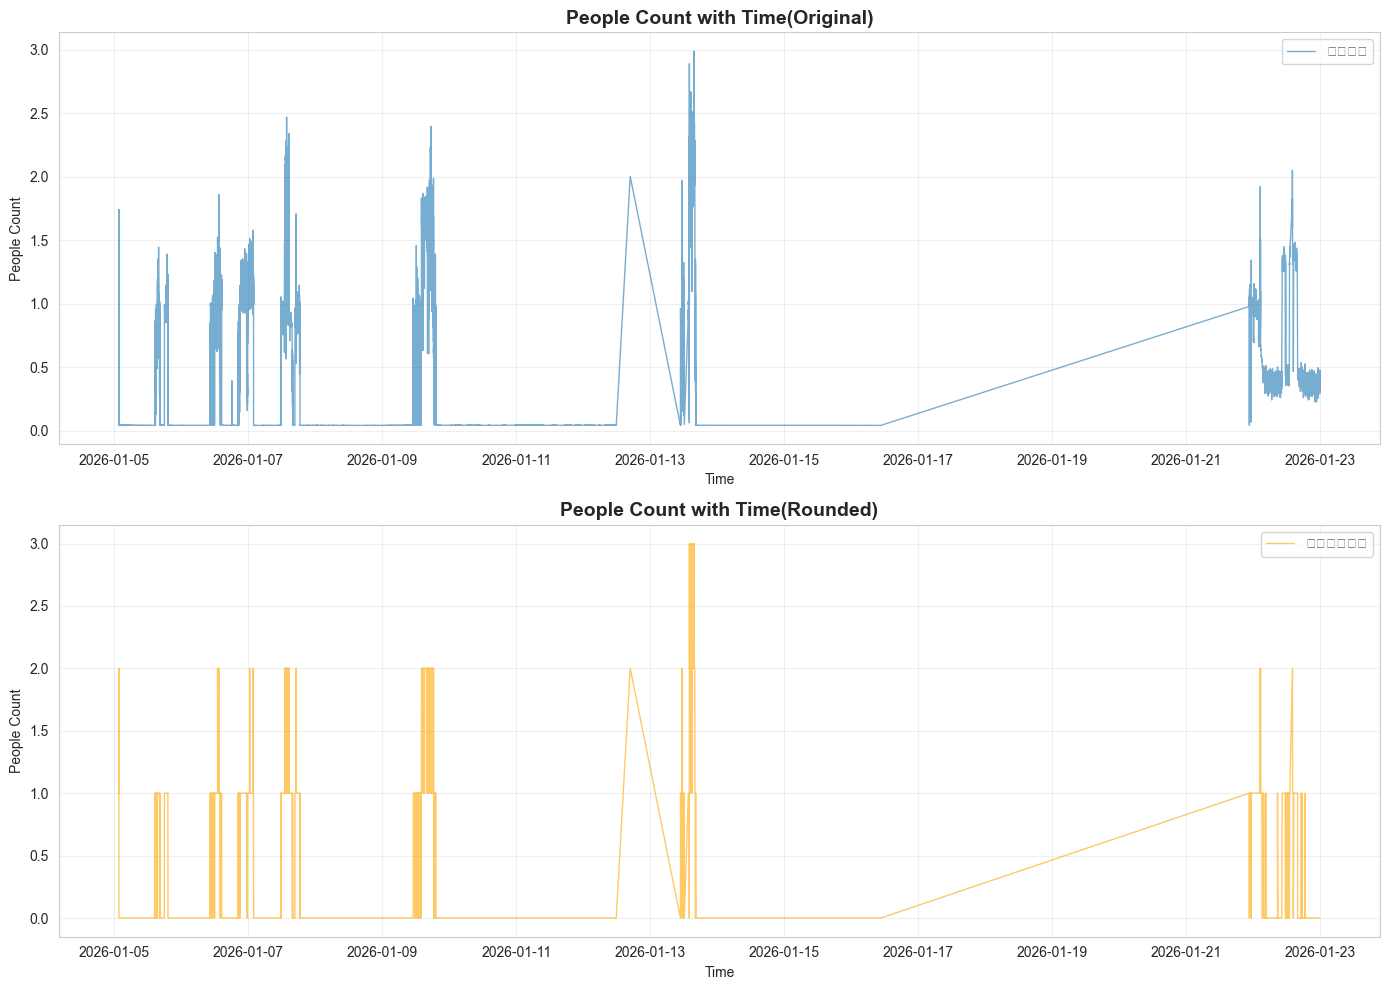

In [20]:
# 人數隨時間的變化趨勢
if not df_people.empty and 'timestamp' in df_people.columns:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # 原始人數（浮點數）
    axes[0].plot(df_people['timestamp'], df_people['people_count'], 
                 alpha=0.6, linewidth=1, label='原始人數')
    axes[0].set_title('People Count with Time(Original)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Time')
    axes[0].set_ylabel('People Count')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 四捨五入後的人數
    axes[1].plot(df_people['timestamp'], df_people['people_count_rounded'], 
                 alpha=0.6, linewidth=1, label='四捨五入人數', color='orange')
    axes[1].set_title('People Count with Time(Rounded)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Time')
    axes[1].set_ylabel('People Count')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ 無法繪製人數時間序列：數據為空或缺少時間戳記列")

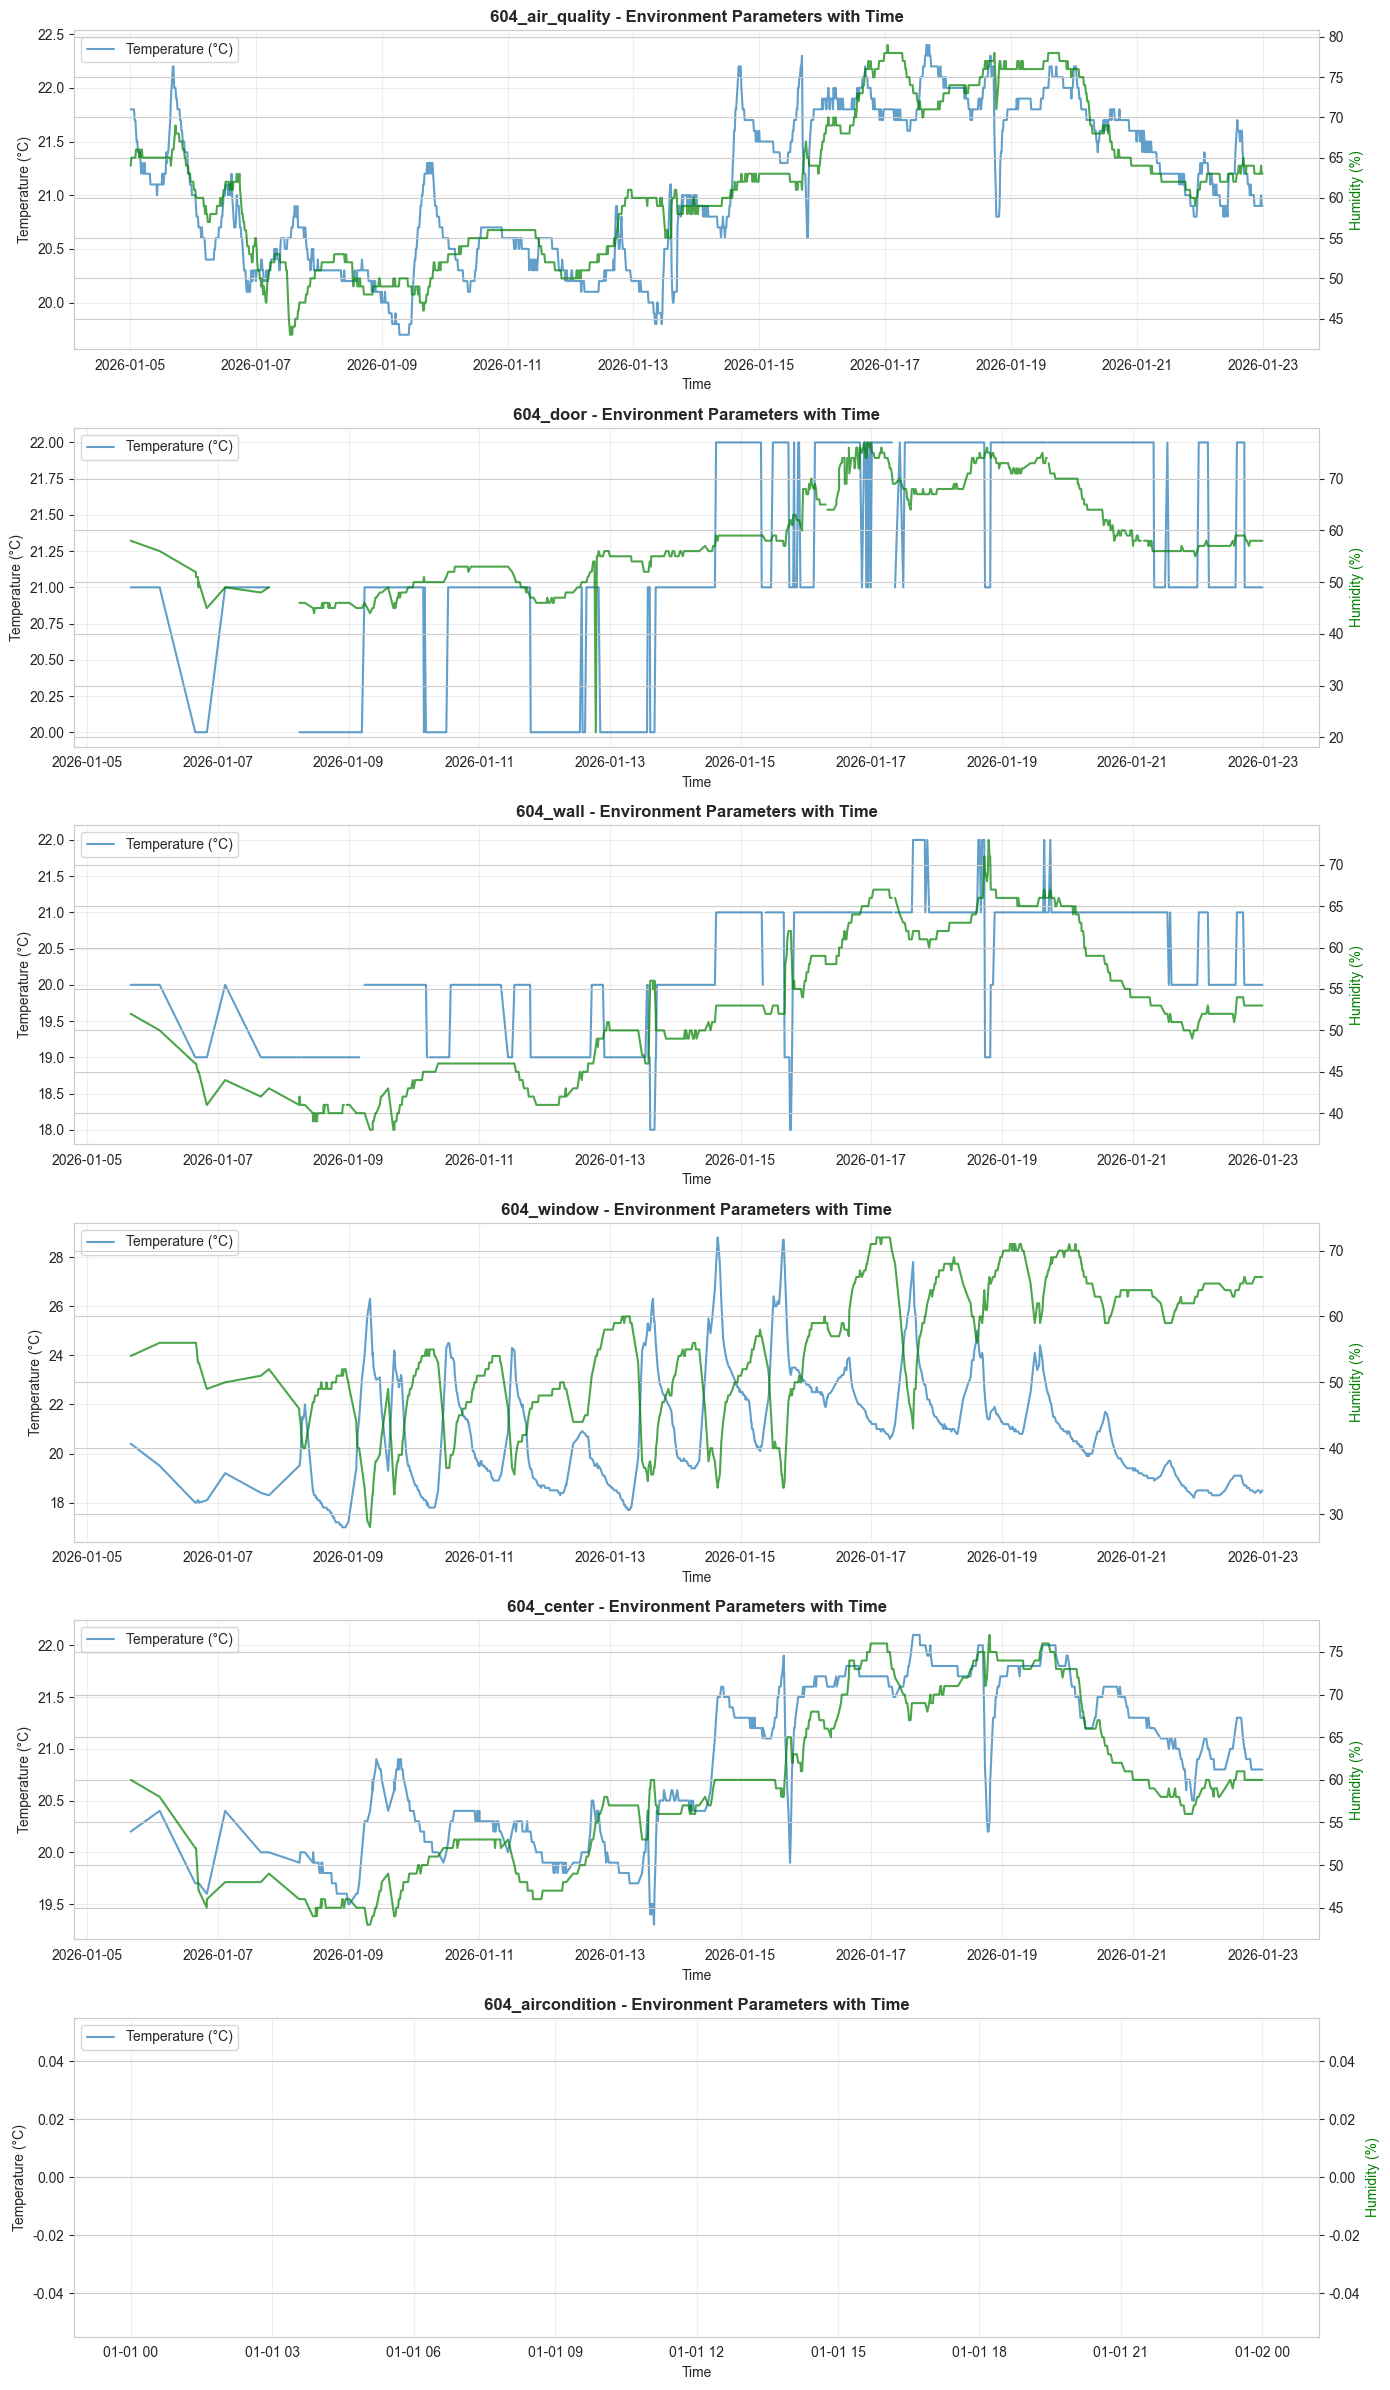

In [23]:
# 環境參數隨時間的變化（按感測器類型分組）
if not df_env.empty and 'time' in df_env.columns:
    # 篩選出主要的環境感測器
    sensor_names = df_env['name'].unique() if 'name' in df_env.columns else []
    
    # 創建子圖
    n_sensors = len(sensor_names)
    if n_sensors > 0:
        fig, axes = plt.subplots(n_sensors, 1, figsize=(14, 4*n_sensors))
        if n_sensors == 1:
            axes = [axes]
        
        for idx, sensor_name in enumerate(sensor_names):
            sensor_data = df_env[df_env['name'] == sensor_name].copy()
            
            # 繪製溫度
            if 'celsius_degree' in sensor_data.columns:
                axes[idx].plot(sensor_data['time'], sensor_data['celsius_degree'], 
                             label='Temperature (°C)', alpha=0.7)
            
            # 繪製濕度
            if 'humidity' in sensor_data.columns:
                ax2 = axes[idx].twinx()
                ax2.plot(sensor_data['time'], sensor_data['humidity'], 
                        label='Humidity (%)', alpha=0.7, color='green')
                ax2.set_ylabel('Humidity (%)', color='green')
            
            axes[idx].set_title(f'{sensor_name} - Environment Parameters with Time', fontsize=12, fontweight='bold')
            axes[idx].set_xlabel('Time')
            axes[idx].set_ylabel('Temperature (°C)')
            axes[idx].legend(loc='upper left')
            axes[idx].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ 沒有找到感測器數據")
else:
    print("⚠️ 無法繪製環境參數時間序列：數據為空或缺少時間戳記列")

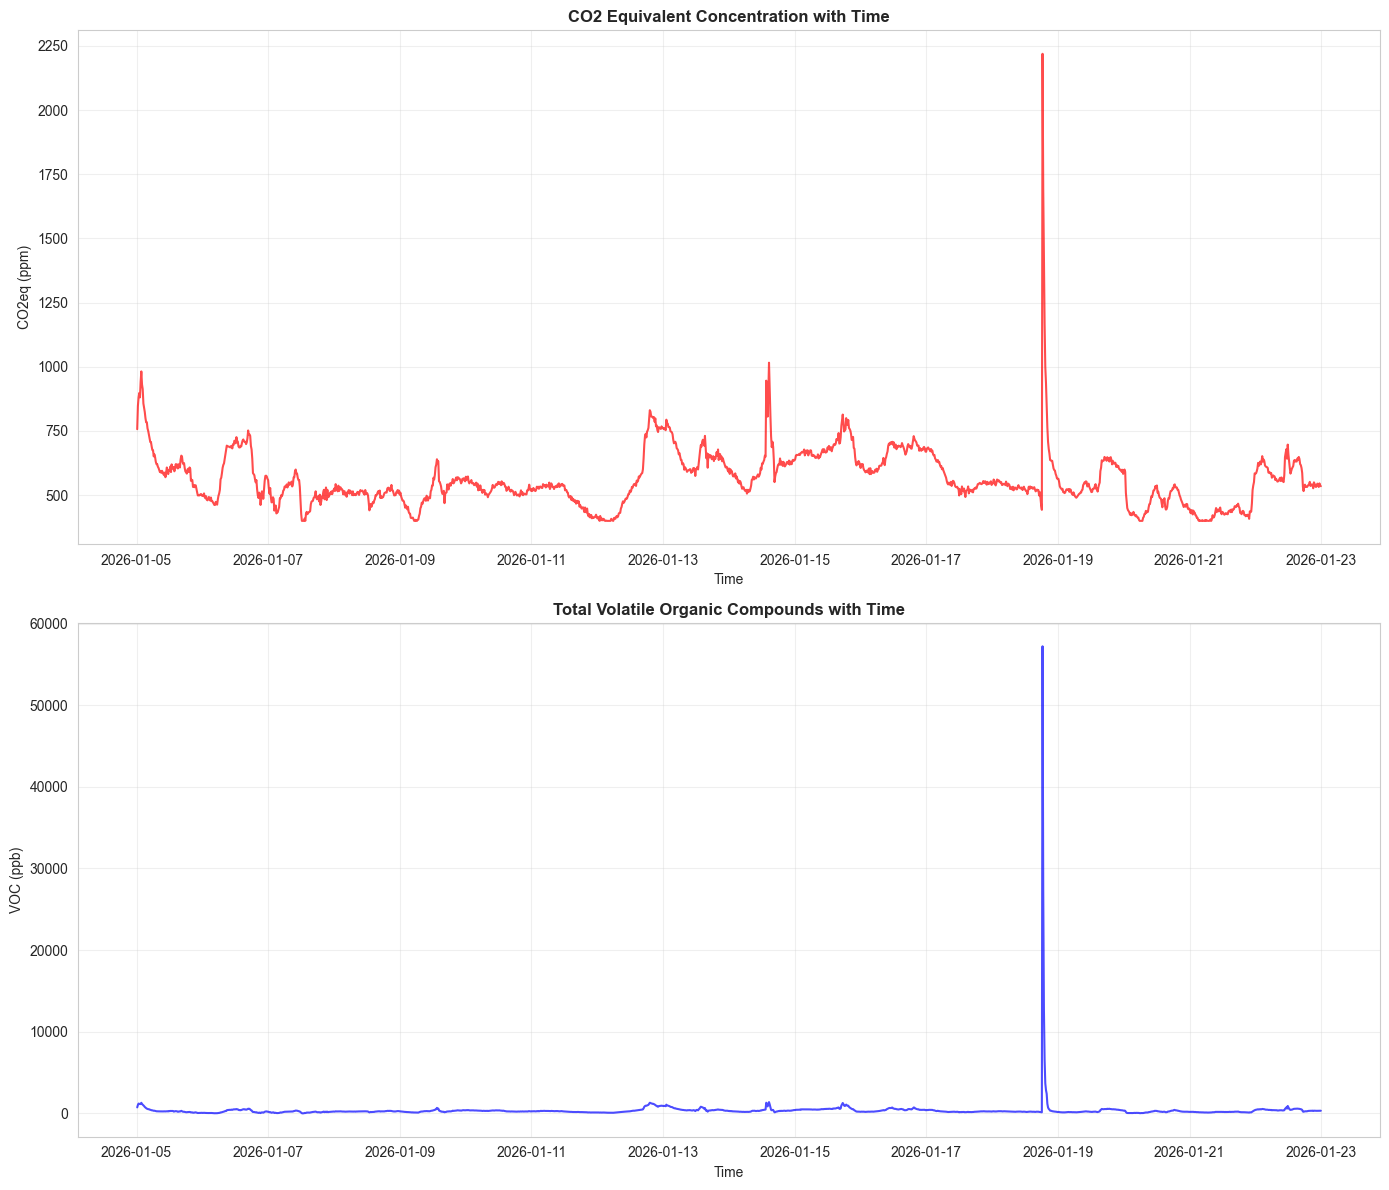

In [34]:
# 空氣品質參數（CO2, VOC）隨時間變化
if not df_env.empty and 'time' in df_env.columns:
    # 篩選空氣品質感測器 604_air_quality、604_window
    air_quality_sensors = df_env[df_env['name'] == '604_air_quality'] if 'name' in df_env.columns else pd.DataFrame()
    
    if not air_quality_sensors.empty:
        fig, axes = plt.subplots(2, 1, figsize=(14, 12))
        
        # CO2
        if 'co2eq' in air_quality_sensors.columns:
            axes[0].plot(air_quality_sensors['time'], air_quality_sensors['co2eq'], 
                        color='red', alpha=0.7, linewidth=1.5)
            axes[0].set_title('CO2 Equivalent Concentration with Time', fontsize=12, fontweight='bold')
            axes[0].set_xlabel('Time')
            axes[0].set_ylabel('CO2eq (ppm)')
            axes[0].grid(True, alpha=0.3)
        
        # VOC
        if 'total_voc' in air_quality_sensors.columns:
            axes[1].plot(air_quality_sensors['time'], air_quality_sensors['total_voc'], 
                        color='blue', alpha=0.7, linewidth=1.5)
            axes[1].set_title('Total Volatile Organic Compounds with Time', fontsize=12, fontweight='bold')
            axes[1].set_xlabel('Time')
            axes[1].set_ylabel('VOC (ppb)')
            axes[1].grid(True, alpha=0.3)
        
        
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ 沒有找到空氣品質感測器數據")
else:
    print("⚠️ 無法繪製空氣品質時間序列：數據為空或缺少時間戳記列")

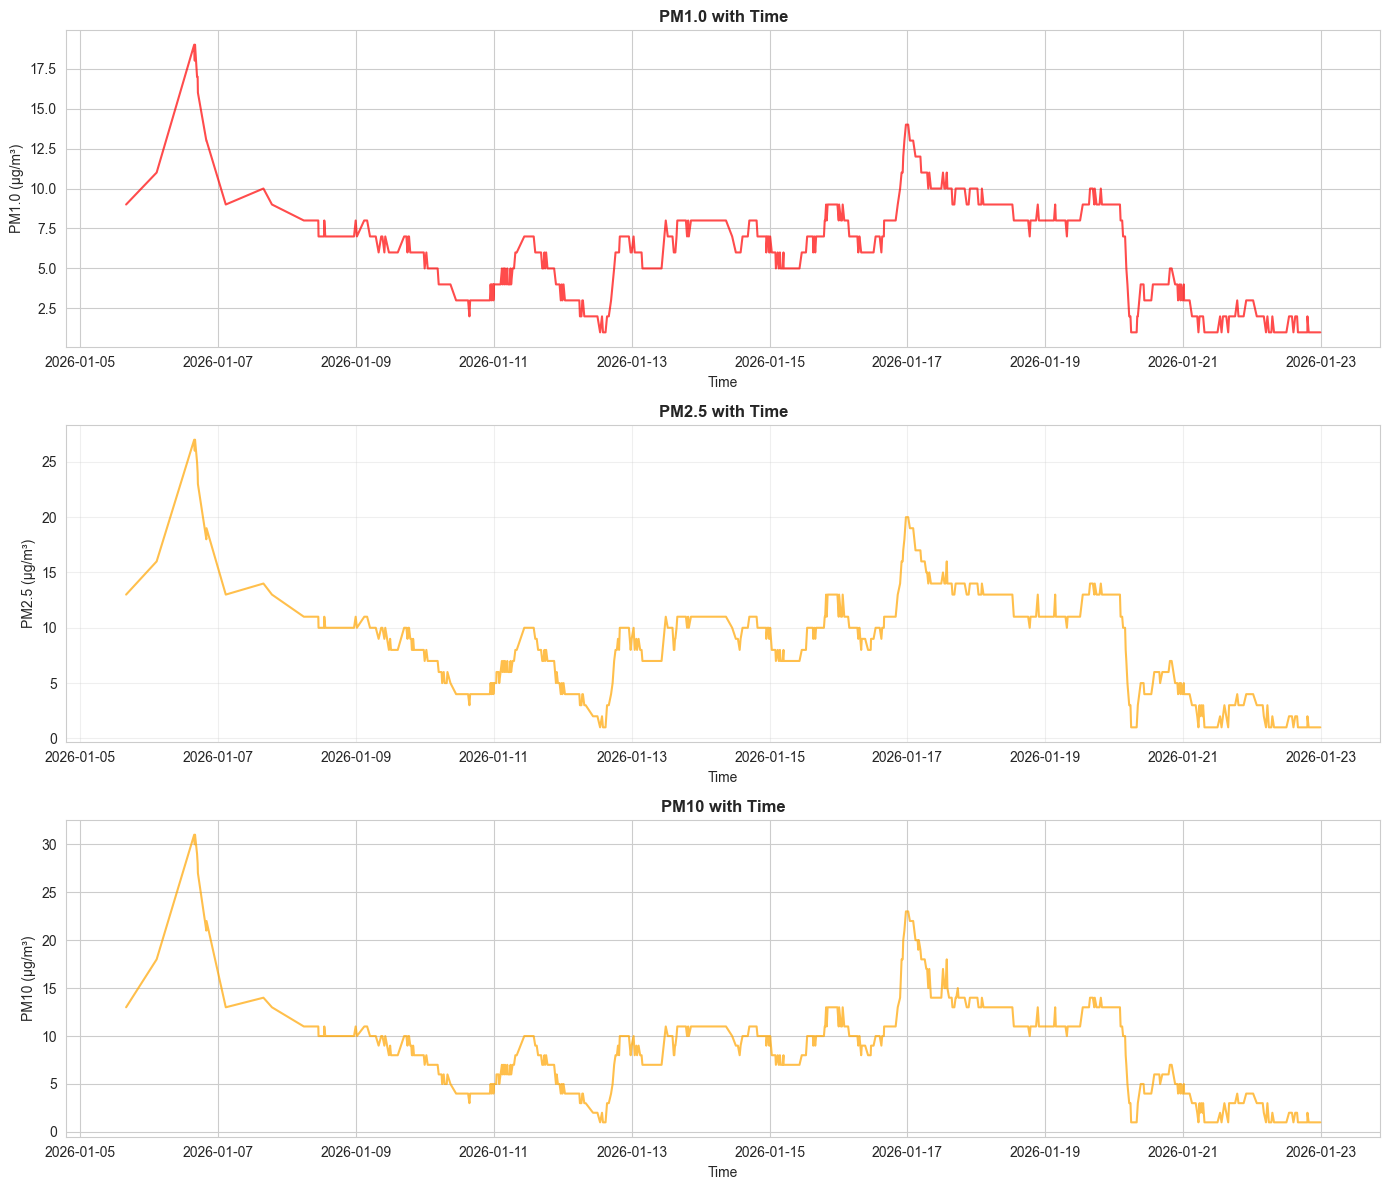

In [30]:
# 空氣品質參數（PM1.0 PM2.5 PM10）隨時間變化
if not df_env.empty and 'time' in df_env.columns:
    # 篩選空氣品質感測器 604_air_quality、604_window
    air_quality_sensors = df_env[df_env['name'] == '604_window'] if 'name' in df_env.columns else pd.DataFrame()
    
    if not air_quality_sensors.empty:
        fig, axes = plt.subplots(3, 1, figsize=(14, 12))
        
        # PM1.0
        if 'pm1_0_atm' in air_quality_sensors.columns:
            axes[0].plot(air_quality_sensors['time'], air_quality_sensors['pm1_0_atm'], 
                        color='red', alpha=0.7, linewidth=1.5)
            axes[0].set_title('PM1.0 with Time', fontsize=12, fontweight='bold')
            axes[0].set_xlabel('Time')
            axes[0].set_ylabel('PM1.0 (μg/m³)')
        # PM2.5
        if 'pm2_5_atm' in air_quality_sensors.columns:
            axes[1].plot(air_quality_sensors['time'], air_quality_sensors['pm2_5_atm'], 
                        color='orange', alpha=0.7, linewidth=1.5)
            axes[1].set_title('PM2.5 with Time', fontsize=12, fontweight='bold')
            axes[1].set_xlabel('Time')
            axes[1].set_ylabel('PM2.5 (μg/m³)')
            axes[1].grid(True, alpha=0.3)
        
        # PM10
        if 'pm10_atm' in air_quality_sensors.columns:
            axes[2].plot(air_quality_sensors['time'], air_quality_sensors['pm10_atm'], 
                        color='orange', alpha=0.7, linewidth=1.5)
            axes[2].set_title('PM10 with Time', fontsize=12, fontweight='bold')
            axes[2].set_xlabel('Time')
            axes[2].set_ylabel('PM10 (μg/m³)')
        
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ 沒有找到空氣品質感測器數據")
else:
    print("⚠️ 無法繪製空氣品質時間序列：數據為空或缺少時間戳記列")

### 3.1 疊圖：人數與環境參數趨勢對比

# 將人數和環境參數（CO2, VOC, PM）畫在同一張圖上，比較趨勢相似性
if not df_people.empty and not df_env.empty:
    # 準備數據：合併人數和環境數據
    air_quality = df_env[df_env['name'] == '604_air_quality'].copy() if 'name' in df_env.columns else pd.DataFrame()
    pm_sensor = df_env[df_env['name'] == '604_window'].copy() if 'name' in df_env.columns else pd.DataFrame()
    
    if not air_quality.empty:
        # 創建時間對齊的數據框
        # 使用人數數據的時間點作為基準
        df_merged_time = df_people[['timestamp', 'people_count']].copy()
        df_merged_time = df_merged_time.sort_values('timestamp').reset_index(drop=True)
        
        # 為每個時間點找到最近的環境數據
        env_vars = {
            'co2eq': air_quality,
            'total_voc': air_quality,
        }
        
        # PM 數據從 604_window 感測器獲取
        if not pm_sensor.empty:
            if 'pm1_0_atm' in pm_sensor.columns:
                env_vars['pm1_0_atm'] = pm_sensor
            if 'pm2_5_atm' in pm_sensor.columns:
                env_vars['pm2_5_atm'] = pm_sensor
            if 'pm10_atm' in pm_sensor.columns:
                env_vars['pm10_atm'] = pm_sensor
        
        # 匹配環境數據
        for var_name, sensor_data in env_vars.items():
            if var_name in sensor_data.columns:
                df_merged_time[var_name] = np.nan
                for idx, row in df_merged_time.iterrows():
                    time_diff = abs((sensor_data['time'] - row['timestamp']).dt.total_seconds())
                    closest_idx = time_diff.idxmin()
                    if time_diff[closest_idx] < 300:  # 5分鐘內
                        df_merged_time.at[idx, var_name] = sensor_data.at[closest_idx, var_name]
        
        # 移除缺失值過多的行
        df_plot = df_merged_time.dropna(subset=['people_count', 'timestamp'])
        
        if len(df_plot) > 0:
            # 方法 1: 標準化疊圖（所有變數標準化到 0-1，便於比較趨勢）
            fig, ax = plt.subplots(figsize=(16, 8))
            
            # 標準化函數
            def normalize(series):
                s_min = series.min()
                s_max = series.max()
                if s_max - s_min > 0:
                    return (series - s_min) / (s_max - s_min)
                else:
                    return series * 0  # 如果所有值相同，返回 0
            
            # 繪製標準化後的數據
            if 'people_count' in df_plot.columns:
                normalized_people = normalize(df_plot['people_count'].dropna())
                ax.plot(df_plot.loc[normalized_people.index, 'timestamp'], normalized_people, 
                       label='人數 (標準化)', linewidth=2, alpha=0.8, color='blue')
            
            if 'co2eq' in df_plot.columns:
                co2_data = df_plot['co2eq'].dropna()
                if len(co2_data) > 0:
                    normalized_co2 = normalize(co2_data)
                    ax.plot(df_plot.loc[normalized_co2.index, 'timestamp'], normalized_co2, 
                           label='CO2 (標準化)', linewidth=2, alpha=0.8, color='red')
            
            if 'total_voc' in df_plot.columns:
                voc_data = df_plot['total_voc'].dropna()
                if len(voc_data) > 0:
                    normalized_voc = normalize(voc_data)
                    ax.plot(df_plot.loc[normalized_voc.index, 'timestamp'], normalized_voc, 
                           label='VOC (標準化)', linewidth=2, alpha=0.8, color='green')
            
            if 'pm1_0_atm' in df_plot.columns:
                pm1_data = df_plot['pm1_0_atm'].dropna()
                if len(pm1_data) > 0:
                    normalized_pm1 = normalize(pm1_data)
                    ax.plot(df_plot.loc[normalized_pm1.index, 'timestamp'], normalized_pm1, 
                           label='PM1.0 (標準化)', linewidth=2, alpha=0.8, color='orange')
            
            if 'pm2_5_atm' in df_plot.columns:
                pm25_data = df_plot['pm2_5_atm'].dropna()
                if len(pm25_data) > 0:
                    normalized_pm25 = normalize(pm25_data)
                    ax.plot(df_plot.loc[normalized_pm25.index, 'timestamp'], normalized_pm25, 
                           label='PM2.5 (標準化)', linewidth=2, alpha=0.8, color='purple')
            
            if 'pm10_atm' in df_plot.columns:
                pm10_data = df_plot['pm10_atm'].dropna()
                if len(pm10_data) > 0:
                    normalized_pm10 = normalize(pm10_data)
                    ax.plot(df_plot.loc[normalized_pm10.index, 'timestamp'], normalized_pm10, 
                           label='PM10 (標準化)', linewidth=2, alpha=0.8, color='brown')
            
            ax.set_title('人數與環境參數趨勢對比（標準化疊圖）', fontsize=14, fontweight='bold', pad=20)
            ax.set_xlabel('時間', fontsize=12)
            ax.set_ylabel('標準化數值 (0-1)', fontsize=12)
            ax.legend(loc='best', fontsize=10)
            ax.grid(True, alpha=0.3)
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
            
            # 方法 2: 多 Y 軸疊圖（保留原始數值，使用不同 Y 軸）
            fig, ax1 = plt.subplots(figsize=(16, 8))
            
            # 左 Y 軸：人數
            color = 'blue'
            ax1.set_xlabel('時間', fontsize=12)
            ax1.set_ylabel('人數', color=color, fontsize=12)
            if 'people_count' in df_plot.columns:
                people_data = df_plot[['timestamp', 'people_count']].dropna()
                ax1.plot(people_data['timestamp'], people_data['people_count'], 
                        color=color, linewidth=2, alpha=0.8, label='人數')
            ax1.tick_params(axis='y', labelcolor=color)
            ax1.grid(True, alpha=0.3)
            
            # 右 Y 軸 1：CO2 和 VOC
            ax2 = ax1.twinx()
            color = 'red'
            ax2.set_ylabel('CO2 (ppm) / VOC (ppb)', color=color, fontsize=12)
            if 'co2eq' in df_plot.columns:
                co2_data = df_plot[['timestamp', 'co2eq']].dropna()
                if len(co2_data) > 0:
                    ax2.plot(co2_data['timestamp'], co2_data['co2eq'], 
                            color='red', linewidth=2, alpha=0.8, linestyle='-', label='CO2 (ppm)')
            if 'total_voc' in df_plot.columns:
                voc_data = df_plot[['timestamp', 'total_voc']].dropna()
                if len(voc_data) > 0:
                    ax2.plot(voc_data['timestamp'], voc_data['total_voc'], 
                            color='green', linewidth=2, alpha=0.8, linestyle='--', label='VOC (ppb)')
            ax2.tick_params(axis='y', labelcolor=color)
            
            # 右 Y 軸 2：PM（使用另一個 Y 軸）
            ax3 = ax1.twinx()
            ax3.spines['right'].set_position(('outward', 60))  # 偏移第二個 Y 軸
            color = 'orange'
            ax3.set_ylabel('PM (μg/m³)', color=color, fontsize=12)
            if 'pm1_0_atm' in df_plot.columns:
                pm1_data = df_plot[['timestamp', 'pm1_0_atm']].dropna()
                if len(pm1_data) > 0:
                    ax3.plot(pm1_data['timestamp'], pm1_data['pm1_0_atm'], 
                            color='orange', linewidth=2, alpha=0.8, linestyle=':', label='PM1.0')
            if 'pm2_5_atm' in df_plot.columns:
                pm25_data = df_plot[['timestamp', 'pm2_5_atm']].dropna()
                if len(pm25_data) > 0:
                    ax3.plot(pm25_data['timestamp'], pm25_data['pm2_5_atm'], 
                            color='purple', linewidth=2, alpha=0.8, linestyle=':', label='PM2.5')
            if 'pm10_atm' in df_plot.columns:
                pm10_data = df_plot[['timestamp', 'pm10_atm']].dropna()
                if len(pm10_data) > 0:
                    ax3.plot(pm10_data['timestamp'], pm10_data['pm10_atm'], 
                            color='brown', linewidth=2, alpha=0.8, linestyle=':', label='PM10')
            ax3.tick_params(axis='y', labelcolor=color)
            
            # 合併圖例
            lines1, labels1 = ax1.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            lines3, labels3 = ax3.get_legend_handles_labels()
            ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, 
                      loc='upper left', fontsize=10)
            
            plt.title('人數與環境參數趨勢對比（多 Y 軸疊圖）', fontsize=14, fontweight='bold', pad=20)
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
            
            # 顯示數據統計
            print("\n" + "="*60)
            print("疊圖數據統計")
            print("="*60)
            print(f"有效數據點數: {len(df_plot)}")
            print("\n各變數的數值範圍:")
            for col in ['people_count', 'co2eq', 'total_voc', 'pm1_0_atm', 'pm2_5_atm', 'pm10_atm']:
                if col in df_plot.columns:
                    data = df_plot[col].dropna()
                    if len(data) > 0:
                        print(f"  {col}: [{data.min():.2f}, {data.max():.2f}] (平均: {data.mean():.2f})")
        else:
            print("⚠️ 沒有足夠的匹配數據來繪製疊圖")
    else:
        print("⚠️ 沒有找到空氣品質感測器數據")
else:
    print("⚠️ 數據不足，無法繪製疊圖")

## 4. 相關性分析

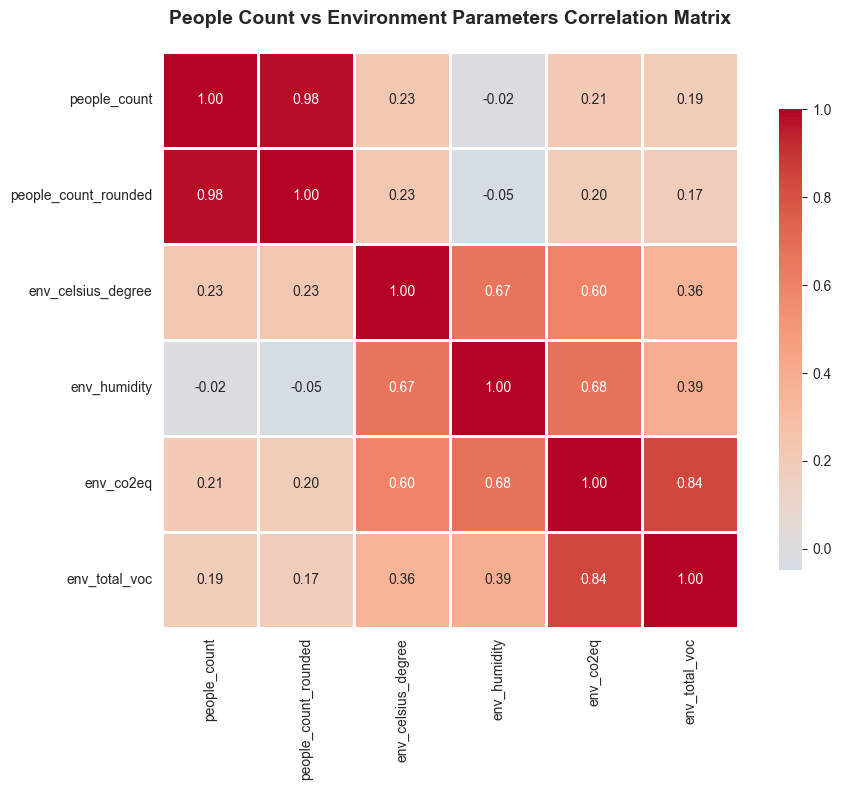


相關係數摘要:
                      people_count  people_count_rounded  env_celsius_degree  \
people_count              1.000000              0.975808            0.226629   
people_count_rounded      0.975808              1.000000            0.228654   
env_celsius_degree        0.226629              0.228654            1.000000   
env_humidity             -0.016576             -0.049110            0.671220   
env_co2eq                 0.208775              0.196326            0.599881   
env_total_voc             0.187886              0.172305            0.359476   

                      env_humidity  env_co2eq  env_total_voc  
people_count             -0.016576   0.208775       0.187886  
people_count_rounded     -0.049110   0.196326       0.172305  
env_celsius_degree        0.671220   0.599881       0.359476  
env_humidity              1.000000   0.677627       0.394406  
env_co2eq                 0.677627   1.000000       0.837161  
env_total_voc             0.394406   0.837161       

In [43]:
# 合併人數和環境數據進行相關性分析
# 將環境數據按時間對齊到人數數據

if not df_people.empty and not df_env.empty:
    # 準備環境數據：取每個時間點最近的環境感測器讀數
    # 這裡我們使用空氣品質感測器的數據作為主要環境指標
    air_quality = df_env[df_env['name'] == '604_air_quality'].copy() if 'name' in df_env.columns else pd.DataFrame()
    
    if not air_quality.empty:
        # 合併數據：使用時間窗口匹配
        df_merged = df_people.copy()
        
        # 為每個人數記錄找到最近的環境數據（在5分鐘內）
        env_cols = ['celsius_degree', 'humidity', 'co2eq', 'total_voc']
        available_cols = [col for col in env_cols if col in air_quality.columns]
        
        for col in available_cols:
            df_merged[f'env_{col}'] = np.nan
        
        # 簡單的時間匹配：找到最近的環境讀數
        for idx, row in df_merged.iterrows():
            if 'timestamp' in row:
                time_diff = abs((air_quality['time'] - row['timestamp']).dt.total_seconds())
                closest_idx = time_diff.idxmin()
                if time_diff[closest_idx] < 7200:  # 2小時內
                    for col in available_cols:
                        df_merged.at[idx, f'env_{col}'] = air_quality.at[closest_idx, col]
        
        # 計算相關係數
        corr_cols = ['people_count', 'people_count_rounded'] + [f'env_{col}' for col in available_cols]
        corr_data = df_merged[corr_cols].corr()
        
        # 繪製相關係數熱力圖
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                   square=True, linewidths=1, cbar_kws={"shrink": 0.8})
        plt.title('People Count vs Environment Parameters Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.show()
        
        print("\n相關係數摘要:")
        print(corr_data)
    else:
        print("⚠️ 沒有找到空氣品質感測器數據，無法進行相關性分析")
else:
    print("⚠️ 數據不足，無法進行相關性分析")

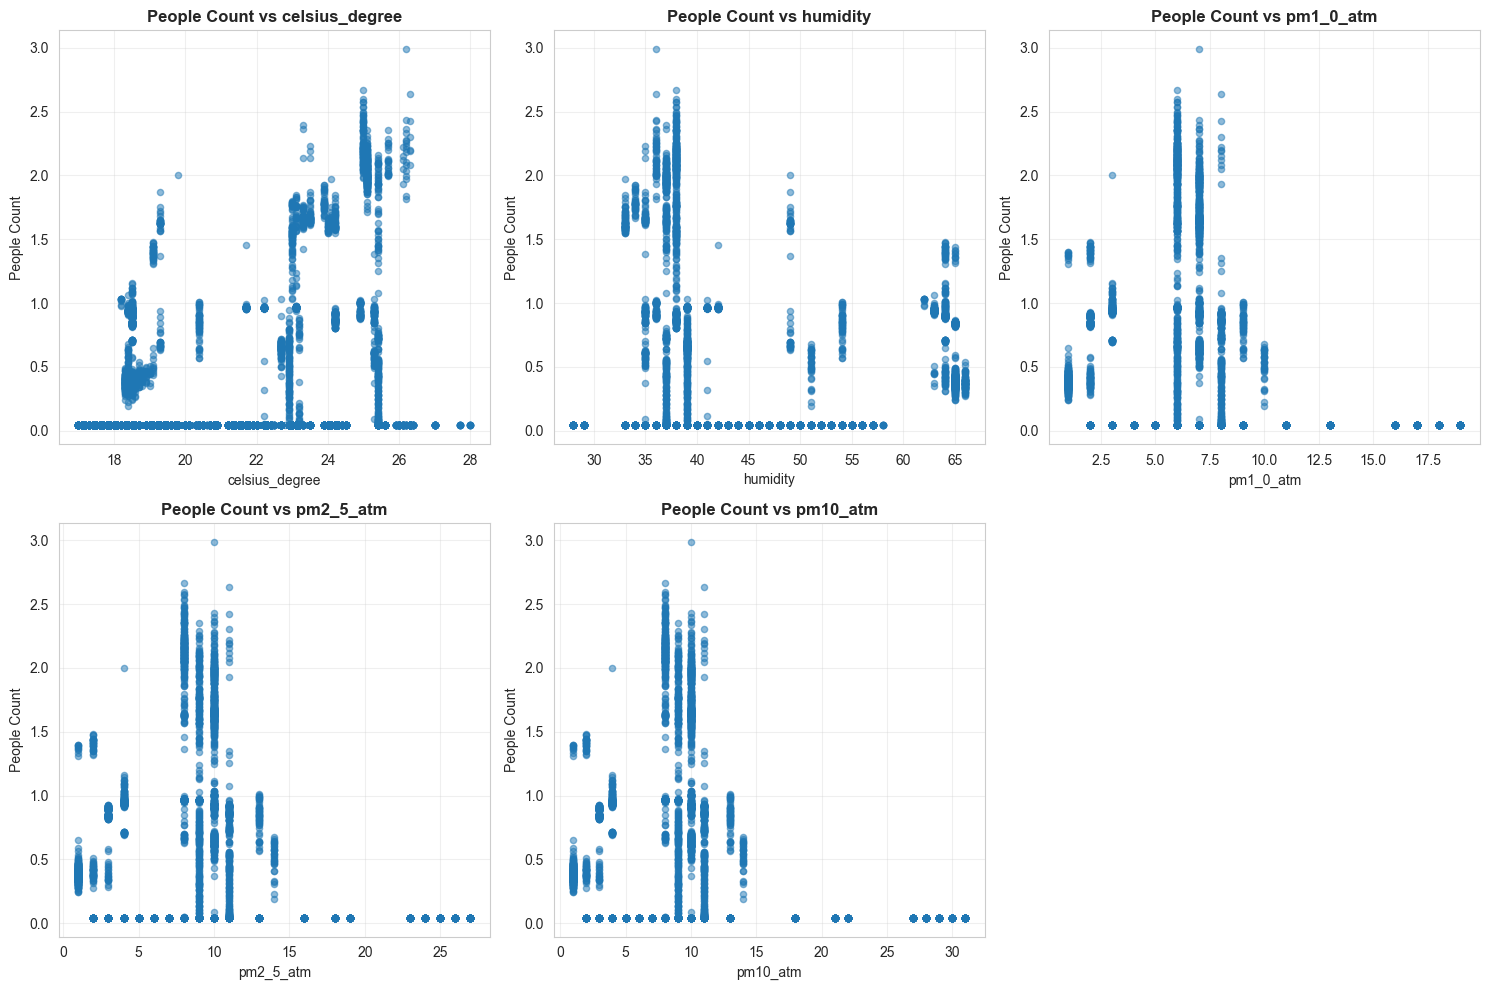

In [40]:
# 散點圖：人數 vs 環境參數
if 'df_merged' in locals() and not df_merged.empty:
    env_cols = [col for col in df_merged.columns if col.startswith('env_')]
    
    if env_cols:
        n_cols = min(3, len(env_cols))
        n_rows = (len(env_cols) + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
        if n_rows == 1:
            axes = axes.reshape(1, -1) if n_cols > 1 else [axes]
        elif n_cols == 1:
            axes = axes.reshape(-1, 1)
        
        axes = axes.flatten()
        
        for idx, col in enumerate(env_cols):
            if idx < len(axes):
                valid_data = df_merged[[col, 'people_count']].dropna()
                if not valid_data.empty:
                    axes[idx].scatter(valid_data[col], valid_data['people_count'], 
                                    alpha=0.5, s=20)
                    axes[idx].set_xlabel(col.replace('env_', ''))
                    axes[idx].set_ylabel('People Count')
                    axes[idx].set_title(f'People Count vs {col.replace("env_", "")}', fontweight='bold')
                    axes[idx].grid(True, alpha=0.3)
        
        # 隱藏多餘的子圖
        for idx in range(len(env_cols), len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ 沒有可用的環境參數數據")
else:
    print("⚠️ 請先執行數據合併步驟")

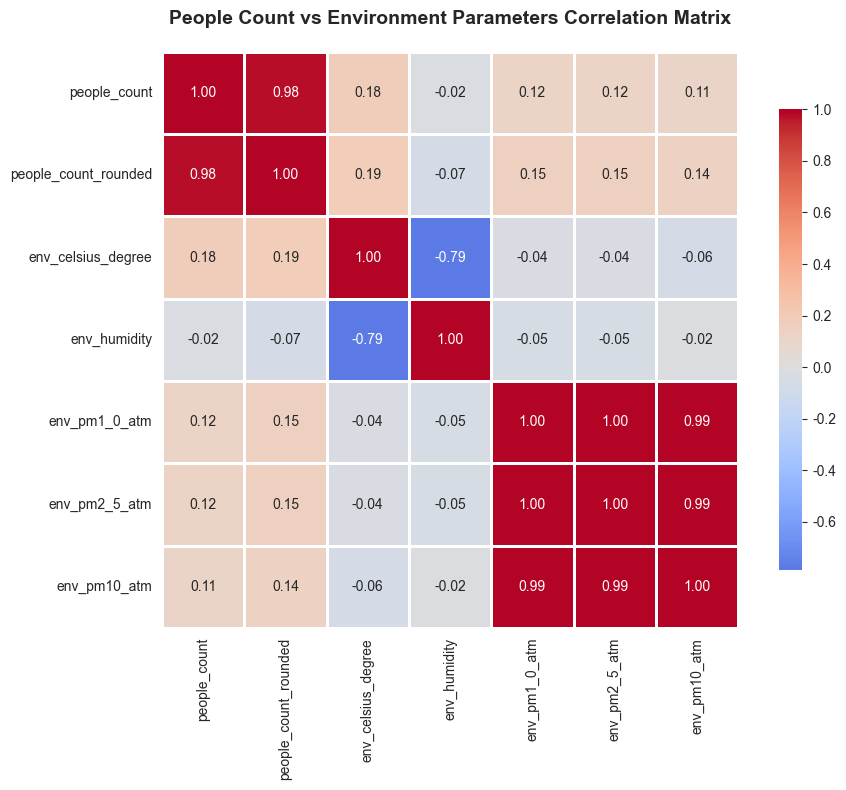


相關係數摘要:
                      people_count  people_count_rounded  env_celsius_degree  \
people_count              1.000000              0.975808            0.175883   
people_count_rounded      0.975808              1.000000            0.188006   
env_celsius_degree        0.175883              0.188006            1.000000   
env_humidity             -0.021554             -0.066166           -0.789027   
env_pm1_0_atm             0.124473              0.150041           -0.040087   
env_pm2_5_atm             0.124911              0.150906           -0.040142   
env_pm10_atm              0.112738              0.135373           -0.063887   

                      env_humidity  env_pm1_0_atm  env_pm2_5_atm  env_pm10_atm  
people_count             -0.021554       0.124473       0.124911      0.112738  
people_count_rounded     -0.066166       0.150041       0.150906      0.135373  
env_celsius_degree       -0.789027      -0.040087      -0.040142     -0.063887  
env_humidity              

In [42]:
# 合併人數和環境數據進行相關性分析
# 將環境數據按時間對齊到人數數據

if not df_people.empty and not df_env.empty:
    # 準備環境數據：取每個時間點最近的環境感測器讀數
    # 這裡我們使用空氣品質感測器的數據作為主要環境指標
    air_quality = df_env[df_env['name'] == '604_window'].copy() if 'name' in df_env.columns else pd.DataFrame()
    
    if not air_quality.empty:
        # 合併數據：使用時間窗口匹配
        df_merged = df_people.copy()
        
        # 為每個人數記錄找到最近的環境數據（在5分鐘內）
        env_cols = ['celsius_degree', 'humidity', 'pm1_0_atm', 'pm2_5_atm', 'pm10_atm']
        available_cols = [col for col in env_cols if col in air_quality.columns]
        
        for col in available_cols:
            df_merged[f'env_{col}'] = np.nan
        
        # 簡單的時間匹配：找到最近的環境讀數
        for idx, row in df_merged.iterrows():
            if 'timestamp' in row:
                time_diff = abs((air_quality['time'] - row['timestamp']).dt.total_seconds())
                closest_idx = time_diff.idxmin()
                if time_diff[closest_idx] < 7200:  # 2小時內
                    for col in available_cols:
                        df_merged.at[idx, f'env_{col}'] = air_quality.at[closest_idx, col]
        
        # 計算相關係數
        corr_cols = ['people_count', 'people_count_rounded'] + [f'env_{col}' for col in available_cols]
        corr_data = df_merged[corr_cols].corr()
        
        # 繪製相關係數熱力圖
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                   square=True, linewidths=1, cbar_kws={"shrink": 0.8})
        plt.title('People Count vs Environment Parameters Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.show()
        
        print("\n相關係數摘要:")
        print(corr_data)
    else:
        print("⚠️ 沒有找到空氣品質感測器數據，無法進行相關性分析")
else:
    print("⚠️ 數據不足，無法進行相關性分析")

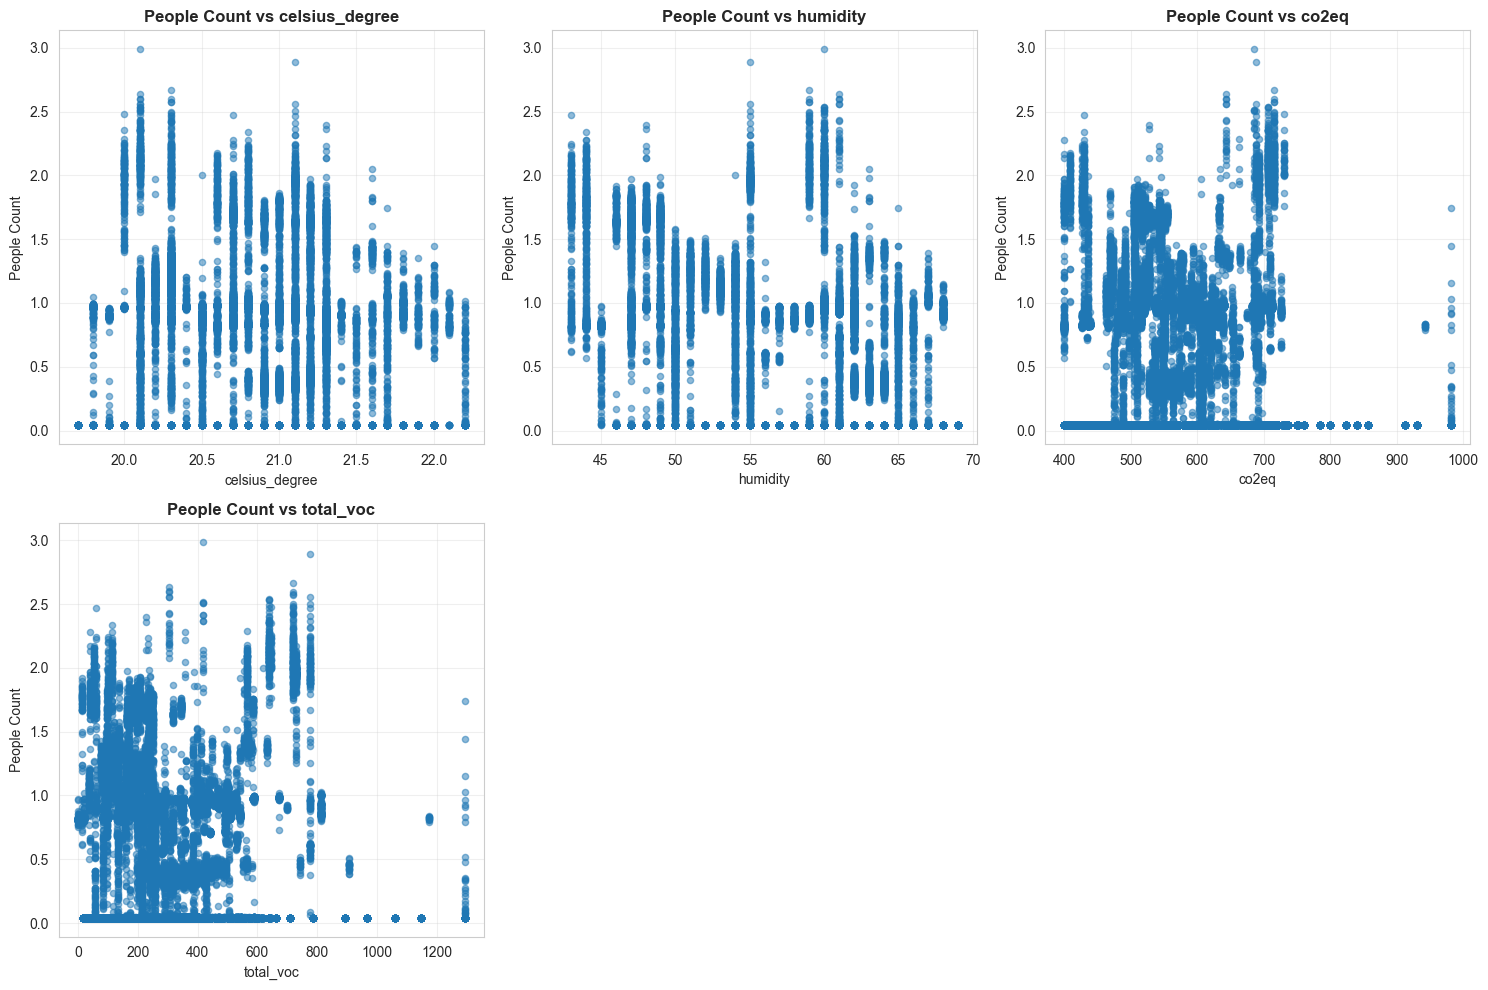

In [46]:
# 散點圖：人數 vs 環境參數
if 'df_merged' in locals() and not df_merged.empty:
    env_cols = [col for col in df_merged.columns if col.startswith('env_')]
    
    if env_cols:
        n_cols = min(3, len(env_cols))
        n_rows = (len(env_cols) + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
        if n_rows == 1:
            axes = axes.reshape(1, -1) if n_cols > 1 else [axes]
        elif n_cols == 1:
            axes = axes.reshape(-1, 1)
        
        axes = axes.flatten()
        
        for idx, col in enumerate(env_cols):
            if idx < len(axes):
                valid_data = df_merged[[col, 'people_count']].dropna()
                if not valid_data.empty:
                    axes[idx].scatter(valid_data[col], valid_data['people_count'], 
                                    alpha=0.5, s=20)
                    axes[idx].set_xlabel(col.replace('env_', ''))
                    axes[idx].set_ylabel('People Count')
                    axes[idx].set_title(f'People Count vs {col.replace("env_", "")}', fontweight='bold')
                    axes[idx].grid(True, alpha=0.3)
        
        # 隱藏多餘的子圖
        for idx in range(len(env_cols), len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ 沒有可用的環境參數數據")
else:
    print("⚠️ 請先執行數據合併步驟")

## 5. 統計分析

In [ ]:
# 人數統計摘要
if not df_people.empty:
    print("="*60)
    print("人數統計摘要")
    print("="*60)
    
    stats_cols = ['people_count', 'people_count_rounded', 'density_map_sum']
    available_stats = [col for col in stats_cols if col in df_people.columns]
    
    if available_stats:
        print(df_people[available_stats].describe())
        
        # 繪製分佈圖
        fig, axes = plt.subplots(1, len(available_stats), figsize=(5*len(available_stats), 4))
        if len(available_stats) == 1:
            axes = [axes]
        
        for idx, col in enumerate(available_stats):
            axes[idx].hist(df_people[col].dropna(), bins=30, alpha=0.7, edgecolor='black')
            axes[idx].set_title(f'{col} 分佈', fontweight='bold')
            axes[idx].set_xlabel(col)
            axes[idx].set_ylabel('頻率')
            axes[idx].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ 沒有可用的統計欄位")
else:
    print("⚠️ 人數數據為空")

In [ ]:
# 環境參數統計摘要
if not df_env.empty:
    print("="*60)
    print("環境參數統計摘要")
    print("="*60)
    
    # 按感測器類型分組統計
    if 'name' in df_env.columns:
        numeric_cols = df_env.select_dtypes(include=[np.number]).columns.tolist()
        
        for sensor_name in df_env['name'].unique():
            sensor_data = df_env[df_env['name'] == sensor_name]
            print(f"\n{sensor_name}:")
            print(sensor_data[numeric_cols].describe())
    else:
        numeric_cols = df_env.select_dtypes(include=[np.number]).columns.tolist()
        print(df_env[numeric_cols].describe())
else:
    print("⚠️ 環境數據為空")

In [ ]:
# 分時段統計（按小時）
if not df_people.empty and 'timestamp' in df_people.columns:
    df_people['hour'] = df_people['timestamp'].dt.hour
    
    hourly_stats = df_people.groupby('hour')['people_count'].agg(['mean', 'std', 'count'])
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # 平均人數按小時
    axes[0].bar(hourly_stats.index, hourly_stats['mean'], alpha=0.7, color='skyblue', edgecolor='black')
    axes[0].set_title('平均人數按小時分佈', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('小時')
    axes[0].set_ylabel('平均人數')
    axes[0].set_xticks(range(24))
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # 數據點數量按小時
    axes[1].bar(hourly_stats.index, hourly_stats['count'], alpha=0.7, color='lightcoral', edgecolor='black')
    axes[1].set_title('數據點數量按小時分佈', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('小時')
    axes[1].set_ylabel('數據點數量')
    axes[1].set_xticks(range(24))
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print("\n按小時統計摘要:")
    print(hourly_stats)
else:
    print("⚠️ 無法進行分時段統計：數據為空或缺少時間戳記列")

## 6. 進階分析

In [ ]:
# 人數與環境參數的迴歸分析
if 'df_merged' in locals() and not df_merged.empty:
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import r2_score, mean_squared_error
    
    env_cols = [col for col in df_merged.columns if col.startswith('env_')]
    
    if env_cols:
        print("="*60)
        print("迴歸分析：人數 vs 環境參數")
        print("="*60)
        
        results = []
        
        for env_col in env_cols:
            # 準備數據
            data = df_merged[[env_col, 'people_count']].dropna()
            
            if len(data) > 10:  # 至少需要10個數據點
                X = data[[env_col]].values
                y = data['people_count'].values
                
                # 線性迴歸
                model = LinearRegression()
                model.fit(X, y)
                y_pred = model.predict(X)
                
                r2 = r2_score(y, y_pred)
                mse = mean_squared_error(y, y_pred)
                
                results.append({
                    '環境參數': env_col.replace('env_', ''),
                    'R²': r2,
                    'MSE': mse,
                    '斜率': model.coef_[0],
                    '截距': model.intercept_
                })
                
                # 繪製迴歸線
                plt.figure(figsize=(8, 6))
                plt.scatter(X, y, alpha=0.5, s=20, label='實際數據')
                plt.plot(X, y_pred, color='red', linewidth=2, label=f'迴歸線 (R²={r2:.3f})')
                plt.xlabel(env_col.replace('env_', ''))
                plt.ylabel('人數')
                plt.title(f'人數 vs {env_col.replace("env_", "")} 迴歸分析', fontweight='bold')
                plt.legend()
                plt.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.show()
        
        if results:
            results_df = pd.DataFrame(results)
            print("\n迴歸分析結果摘要:")
            print(results_df.to_string(index=False))
        else:
            print("⚠️ 沒有足夠的數據進行迴歸分析")
    else:
        print("⚠️ 沒有可用的環境參數數據")
else:
    print("⚠️ 請先執行數據合併步驟")

## 7. 總結與結論

根據以上分析，我們可以得出以下結論：

1. **時間趨勢**：觀察人數和環境參數隨時間的變化模式
2. **相關性**：識別人數與哪些環境參數有較強的相關性
3. **統計特徵**：了解數據的分佈和異常情況
4. **預測潛力**：評估使用環境參數預測人數的可能性

### 建議

- 根據時間序列分析，可以識別使用模式（例如：高峰時段）
- 根據相關性分析，可以找出影響人數的主要環境因素
- 根據統計分析，可以檢測異常情況並進行數據品質控制

In [ ]:
# 異常值檢測（使用 IQR 方法）
if not df_people.empty:
    print("="*60)
    print("異常值檢測（人數數據）")
    print("="*60)
    
    if 'people_count' in df_people.columns:
        Q1 = df_people['people_count'].quantile(0.25)
        Q3 = df_people['people_count'].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df_people[(df_people['people_count'] < lower_bound) | 
                            (df_people['people_count'] > upper_bound)]
        
        print(f"正常範圍: [{lower_bound:.2f}, {upper_bound:.2f}]")
        print(f"異常值數量: {len(outliers)} ({len(outliers)/len(df_people)*100:.2f}%)")
        
        # 視覺化異常值
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.scatter(df_people['timestamp'], df_people['people_count'], 
                  alpha=0.5, s=20, label='正常值')
        if not outliers.empty:
            ax.scatter(outliers['timestamp'], outliers['people_count'], 
                      color='red', s=50, label='異常值', marker='x')
        ax.axhline(y=lower_bound, color='orange', linestyle='--', label='下界')
        ax.axhline(y=upper_bound, color='orange', linestyle='--', label='上界')
        ax.set_title('人數異常值檢測', fontsize=14, fontweight='bold')
        ax.set_xlabel('時間')
        ax.set_ylabel('人數')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ 缺少 people_count 欄位")
else:
    print("⚠️ 人數數據為空")